In [ ]:
#####################################################
###         Select event generator:               ###
###             0 : QGSM                          ###
###             1 : EPOS                          ###
###             2 : PHQMD                         ###
###             3 : UrQMD                         ###
##################################################### 

EVENT_GENERATOR = 1

#####################################################
###         Select features type:                 ###
###             0 : Baseline physical features    ###
###                                               ###
##################################################### 

FEATURES_TYPE = 0

#####################################################
###         Select configuration properties       ###
#####################################################
generators = {0: 'QGSM', 1: 'EPOS', 2: 'PHQMD', 3: 'UrQMD'}

collisionEnergy = 11.006
detectorInRadius = 0.025 #0.125          # Внутренний радиус детекторов
detectorOutRadius = 0.25         # Внешний радиус детекторов
detectorDistances = [4]  # Расстояния установки детекторов
timeAccuracy = 0.05                # Точность с которой пишется время прилета в нс
nAngles = 16                       # На сколько сегментов детектор разбивается по углам
nRadii = 22                        # На сколько сегментов детектор разбивается по
outputPath = 'data/modeled/'
nameOfFile = f'PD213_{generators.get(EVENT_GENERATOR)}_EventFeatures'         # Имя файла, в который будет записана информация. Записывается в папку output_path с расширением .dat
NFiles = 100                 # Количество файлов исходных данных  (у меня максимум QGSM: 100; EPOS: 181)


#####################################################
###        End of configuration properties        ###
#####################################################
import numpy as np
import math
from collections import Counter

# Set directory with input raw generator files
if EVENT_GENERATOR == 0:
    folder_path = 'data/source/'               # Путь в папку где лежат исходные данные QGSM
elif EVENT_GENERATOR == 1:
    # folder_path = 'data/sourceEPOS_full/'                 # Тест с форматом OSCAR1999a  BASIC mode по <200 событий, полные
    folder_path = 'data/sourceEPOS_2k/'                 # Тест с форматом OSCAR1999a  BASIC mode по 2000 событий, только статус 0
elif EVENT_GENERATOR == 2:
    folder_path = 'data/sourcePHQMD_1110fmc_2025/MSTStab/'
elif EVENT_GENERATOR == 3:
    # folder_path = 'tmp/st097914/results/out/UrQMD4-XeW-SqSnn2.2GeV-0-25fm-pt1/'                 # UrQMD В формате OCS1997A
    folder_path = 'tmp/st076410/results/out/urqmd-XeW-4GeV-target/'                 # UrQMD В формате OCS1997A
else:
    raise Exception("Generator format should be chosen")

speed_of_light = 299792456      # m / s
PROTON_MASS = 0.938272          # mass in GeV/c^2
NEUTRON_MASS = 0.939566          # mass in GeV/c^2
GOLD_NUCLEI_RADIUS = 7.3
avg_pion_times = [3.345, 5.675, 8.355]
n_lines = 3
maximum_hits = 150

masses_dict = {'211': 0.139570, '2212': 0.938272, '3112': 1.197449, '321': 0.493677, '3222': 1.18937,
              '3312': 1.32171, '3334': 1.67245, '-211': 0.139570, '-2212': 0.938272, '-3112': 1.197449, 
              '-321': 0.493677, '-3222': 1.18937, '-3312': 1.32171, '-3334': 1.67245, '100121': 1.875613,
              '431': 1.86966, '-431': 1.86966, '4214': 1.18937, '-4214': 1.18937, '4222': 1.18937,'-4222': 1.18937,
              '4224': 1.192642, '411': 1.86962, '-411': 1.86962, '4122': 2.28646, '4212': 2.4529}

charged_particles_list = ['211', '2212','3112', '321', '3222', '3312', '3334',
                          '-211', '-2212','-3112', '-321', '-3222', '-3312', '-3334']

# Данные взяты из EPOS 1 user guide
charged_particles_list_osc99a = ['120', '130', '240', '340', '150', '121', '131',
                          '241', '341', '151',
                          '-120', '-130','-240', '-340', '-150', '-121', '-131',
                          '-241', '-341', '-151',
                          '1120', '1130', '2230', '2330', '1140', '1240', '2140',
                          '1340', '3140', '1440', '2440', '3440', '1111', '2221', 
                          '1131', '2231', '3331', '1141', '1241', '1341', '1441',
                          '2441', '3441', '4441',
                          '-1120', '-1130', '-2230', '-2330', '-1140', '-1240', '-2140',
                          '-1340', '-3140', '-1440', '-2440', '-3440', '-1111', '-2221', 
                          '-1131', '-2231', '-3331', '-1141', '-1241', '-1341', '-1441',
                          '-2441', '-3441', '-4441',]

class Particle_hit:
    def __init__(self, index, time, px, py, pz, pm) -> None:
        self.index = index
        self.time = time
        self.px = px
        self.py= py
        self.pz = pz
        self.p = np.sqrt(px**2 + py**2 + pz**2)
        self.pT = np.sqrt(px**2 + py**2)
        self.sign = np.sign(pz)
        self.mass = pm

# Разбиение детектора на n_radii одинаковых колец
detectorWidth = detectorOutRadius - detectorInRadius
oneRingWidth = detectorWidth / nRadii
ringsWidth = []
# print(f'R = {detector_out_radius}; Nrad = {n_radii}; One Ring = {one_ring_width:.3f}')
for i in range(nRadii):
    ringsWidth.append(oneRingWidth)
# Вычисление координат границ детекторов используя ширины колец
detector_borders = []
for i in range(len(ringsWidth)):
    rad = detectorInRadius
    for j in range(i, 0, -1):
        rad += ringsWidth[j - 1]
    detector_borders.append(rad)
detector_borders.append(detectorOutRadius)
print(ringsWidth)
print("Границы радиального разбиения на {}".format(detector_borders))

class Collision_event:
    def __init__(self, b, coordinate, particles) -> None:
        self.b = b
        self.coordinate = coordinate
        self.multiplicity = 0
        self.chargedMultiplicity = 0
        self.centralChargedMultiplicity = 0
        self.particles = particles
        self.spectatorNeutronsEnergy = 0

    
    
    def fillEventAttributes(self):
        self.NForward = np.sum([1 if p.sign > 0 else 0 for p in self.particles]) / self.chargedMultiplicity
        self.NBackward = 1 - self.NForward  

        self.assymetryFB = (self.NForward - self.NBackward) / (self.NForward + self.NBackward + 0.000001)
        self.absAssymetryFB = abs(self.assymetryFB)
        self.avgAngleCos = np.mean([np.sqrt(p.px **2 + p.py**2) / np.sqrt(p.pz** 2 + p.px **2 + p.py**2) for p in self.particles])


        times = [p.time for p in self.particles]
        times = np.sort(times)
        n = len(times)

        self.avgTime = np.mean(times)
        self.rmsTime = rmsArray(times)
        if (n == 0):
            self.time10thPercentile = 0
            self.time50thPercentile = 0
            self.time90thPercentile = 0
        else:    
            self.time10thPercentile = times[n // 10]
            self.time50thPercentile = times[n // 2]
            self.time90thPercentile = times[int(n // (10/9))]

    def fillRawDetectorData(self):
        hits = []
        # filter particles that hit detector
        for p in self.particles:
            p_along = abs(p.pz)                                    
            p_across = np.sqrt(p.px**2+p.py**2)
            under_upper_bound = (p_across / p_along) < (detectorOutRadius / detectorDistances[0])
            above_lower_bound = (p_across / p_along) > (detectorInRadius / detectorDistances[0])
            hit_detector =  under_upper_bound and above_lower_bound
            if hit_detector:
                hits.append(p)      
        
        self.eventData = [[], [], []]
        all_hits = sorted(hits, key=lambda x: (x.time))    # all hits for one event
        eventDataMatrix = np.zeros((2, nAngles, nRadii), dtype=np.float32)

        for hit in all_hits:    # Iterate over all particle hit
            # # Simulate detector efficiency
            # if np.random.random() > efficiency:
            #     continue
            det_value = 1
            if hit.pz > 0 :
                det_value = 2
            det_num = 0
            dir_num = (det_value - 1) % 2

            # Применяем нелинейное преобразование времени(записанного с заданной точностью), используя информацию о времени пролета пионов

            # Старый способ
            particle_time = timeAccuracy * ((hit.time * 10**9)// timeAccuracy)  
            particle_value = 1 / (particle_time - avg_pion_times[det_num]*detectorDistances[det_num])                                                                # CHANGED !!!
            # particle_value = particle_time

            pModule = np.sqrt(hit.px**2 + hit.py**2 + hit.pz**2)
            px_normed = hit.px / pModule
            py_normed = hit.py / pModule

            angle = np.arctan2(px_normed, py_normed)
            radius = np.sqrt(px_normed ** 2 + py_normed ** 2)
            angle_bin = np.floor(nAngles*(angle/2/np.pi+0.5))
            angle_bin = angle_bin.astype(int)
            if angle_bin >= nAngles:
                angle_bin -= 1

            # Вычисление радиальной координаты прилета частицы
            current_distance = detectorDistances[det_num]
            rad = radius * current_distance
        
            isHit = False
            r_bin = 0
            # Определим бин по радиусу
            for i in range(len(detector_borders) - 1):
                if detector_borders[i] < rad <= detector_borders[i+1]:
                    r_bin = i
                    isHit = True
                    break

            # Если в эту ячейку еще не прилетала частица
            if eventDataMatrix[det_num * 2 + dir_num, angle_bin, r_bin] == 0 and isHit:
                eventDataMatrix[det_num * 2 + dir_num, angle_bin, r_bin] = particle_value

                # if isHit:
                self.eventData[0].append(particle_value)
                self.eventData[1].append(r_bin * nAngles + angle_bin + 1)
                self.eventData[2].append(det_value)
                                                

def isPion(pIndex: str) -> bool:
    if EVENT_GENERATOR in (0, 2):
        return pIndex in ['-211', '211']
    elif EVENT_GENERATOR == 1:
        return pIndex in ['120', '-120']
    else:
        raise Exception('Unknown generator format')

def isKaon(pIndex: str) -> bool:
    if EVENT_GENERATOR in (0, 2):
        return pIndex in ['-321', '321']
    elif EVENT_GENERATOR == 1:
        return pIndex in ['130', '-130']
    else:
        raise Exception('Unknown generator format')

def isSigma(pIndex: str) -> bool:
    if EVENT_GENERATOR in (0, 2):
        return pIndex in ['3112', '3222']
    elif EVENT_GENERATOR == 1:
        return pIndex in ['1130', '2230']
    else:
        raise Exception('Unknown generator format')

def isProton(pIndex: str) -> bool:
    if EVENT_GENERATOR in (0, 2):
        return pIndex == '2212'
    elif EVENT_GENERATOR == 1:
        return pIndex == '1120'
    else:
        raise Exception('Unknown generator format')
    
def isNeutron(pIndex: str) -> bool:
    if EVENT_GENERATOR in (0, 2):
        return pIndex == '2112'
    elif EVENT_GENERATOR == 1:
        return pIndex == '1220'
    else:
        raise Exception('Unknown generator format')

def isSpectator(p: Particle_hit, pErr=0.05, eErr=0.05) -> bool:
    if EVENT_GENERATOR == 0 or EVENT_GENERATOR == 2: 
        if p.index not in ['2212', '2112'] and len(p.index) != 10:
            return False
    
    if EVENT_GENERATOR == 1:
        if p.index not in ['1120', '1220']:
            return False

    # if abs(p.pT / p.p) > pErr:
    #     return False
    
    nNucleons = 1
    if len(p.index) == 10:
        nNucleons = (int(p.index) % 10000) // 10   

    pE = np.sqrt(p.p**2 + p.mass**2)
    if abs(pE - nNucleons * collisionEnergy / 2) > eErr * nNucleons * collisionEnergy / 2:
        return False
    
    return True
   



# Определение массы частицы по ее индексу
def get_particle_mass(p_index: str) -> float:
    if len(p_index) != 10:
        return masses_dict[p_index]
    else:
        m = (int(p_index) % 10000) // 10
        return float(m * PROTON_MASS)
        
# Вычисление скорости частицы по ее импульсу и индексу   
def calc_velocity(p: float, pz: float, ptype: str) -> float:
    return abs(pz) / np.sqrt(get_particle_mass(ptype) **2 + p**2 / 1**2)

# Вычисление скорости частицы по ее импульсу и массе  
def calc_velocity_by_mass(p: float, pz: float, pmass: str) -> float:
    return abs(pz) / np.sqrt(pmass **2 + p**2 / 1**2)

# Вычисление времени пролета по скорости и расстоянию до детектора
def calc_time(v: float, distance: float) -> float:
    c = 2.99722458 * 10**8
    velocity = v * c
    time = distance / velocity
    return time

# Поворот на угол, задаваемый случайным числом randomizer
def random_rotation(angle, max_angle, randomizer):
    new_angle = angle + randomizer * max_angle
    if (new_angle == np.pi) or (new_angle == -np.pi):
        new_angle -= 0.00000001
    if new_angle > np.pi:
        new_angle -= 2*np.pi
    elif new_angle < -np.pi:
        new_angle += 2*np.pi
    return new_angle

def get_p_value(p_index: str) -> int:
    if (p_index == '211' or p_index == '-211'):          # pions
        return 1
    elif (p_index == '2212' or p_index == '-2212'):         # protons
        return 2
    else:
        return 3

# Нормировка времени пролета (t_light / t) на расстоянии current_distance
def normalize_time(t: float, dist: float):
    t_light = dist  * (10**9) / speed_of_light
    return  t_light / t

def getIntersectionRadius(R: float, b: float) -> float:
    return max(R - b/2, 0)

def calculateIntersectionVolume(R: float, b: float) -> float:
    t = getIntersectionRadius(R, b)
    return 2 * np.pi * ( t**2 ) * (R - t / 3)

# Return is particle charged or not by its id
def isCharged(mc_id) -> bool:
    if len(mc_id) == 10 or mc_id in charged_particles_list:
        return True
    else:
        return False

def isCharged_osc99a(mc_id) -> bool:
    # if len(mc_id) == 9 or mc_id in charged_particles_list_osc99a:
    #     return True
    # else:
    #     return False
    return mc_id in charged_particles_list_osc99a

def pseudorapidity_ln(p, p_L) -> float:
    return 0.5 * np.log((abs(p) + p_L) / (abs(p) - p_L))

def sgn(value) -> int:
    if value >= 0.0 :
        return 1
    else: 
        return -1
    
def pseudorapidityByTan(radius, length): 
  angle = np.arctan2(radius, length)
  return -1 * np.log( np.tan(angle / 2) )

def rmsArray(arr: list) -> float:
    squared = [x**2 for x in arr]
    mean = np.mean(arr)
    meanOfSquared = np.mean(squared)

    return np.sqrt( meanOfSquared - mean**2 )

attributesList = ['chargedMultiplicity', 'NForward', 'NBackward', 'assymetryFB', 'absAssymetryFB', 'avgAngleCos']
timeAttributes = [{ 'name': 'avgTime', 'bottom': 13 * 1e-9, 'top':  17 * 1e-9 },
                  { 'name': 'rmsTime', 'bottom': -1 * 1e-9, 'top':  20 * 1e-9 },
                  { 'name': 'time10thPercentile', 'bottom': 13.38 * 1e-9, 'top':  13.6 * 1e-9 },
                  { 'name': 'time50thPercentile', 'bottom': 13.5 * 1e-9, 'top':  14.4 * 1e-9 },
                  { 'name': 'time90thPercentile', 'bottom': 13 * 1e-9, 'top':  22 * 1e-9 },
                #   { 'name': 'detector_avgTime', 'bottom': 13 * 1e-9, 'top':  17 * 1e-9 },
                #   { 'name': 'detector_rmsTime', 'bottom': -1 * 1e-9, 'top':  20 * 1e-9 },
                #   { 'name': 'detector_time10thPercentile', 'bottom': 13.38 * 1e-9, 'top':  13.6 * 1e-9 },
                #   { 'name': 'detector_time50thPercentile', 'bottom': 13.5 * 1e-9, 'top':  14.4 * 1e-9 },
                #   { 'name': 'detector_time90thPercentile', 'bottom': 13 * 1e-9, 'top':  22 * 1e-9 },
                ]
allAttributes = attributesList + [a['name'] for a in timeAttributes]

def writeEvent(outf, e: Collision_event):
    outf.write(f'{str(e.b)}')
    for attr in allAttributes:
        outf.write(f' {getattr(e, attr)}')
    outf.write(' ')
    evdata2 = np.array(e.eventData)

    event_data_new = np.array(np.c_[evdata2, np.zeros((n_lines, maximum_hits - evdata2.shape[1]))])                                           #
    output = np.reshape(event_data_new, (n_lines, 1, -1)).astype(np.float32)

    for j in range(output.shape[0]):    # write into file
        for i in range(output.shape[2]):
            outf.write(str(output[j][0][i]))
            outf.write(' ')
        outf.write('   ')
    outf.write('\n')


[0.010227272727272727, 0.010227272727272727, 0.010227272727272727, 0.010227272727272727, 0.010227272727272727, 0.010227272727272727, 0.010227272727272727, 0.010227272727272727, 0.010227272727272727, 0.010227272727272727, 0.010227272727272727, 0.010227272727272727, 0.010227272727272727, 0.010227272727272727, 0.010227272727272727, 0.010227272727272727, 0.010227272727272727, 0.010227272727272727, 0.010227272727272727, 0.010227272727272727, 0.010227272727272727, 0.010227272727272727]
Границы радиального разбиения на [0.025, 0.03522727272727273, 0.045454545454545456, 0.05568181818181818, 0.0659090909090909, 0.07613636363636363, 0.08636363636363635, 0.09659090909090907, 0.1068181818181818, 0.11704545454545452, 0.12727272727272726, 0.13749999999999998, 0.1477272727272727, 0.15795454545454543, 0.16818181818181815, 0.17840909090909088, 0.1886363636363636, 0.19886363636363633, 0.20909090909090905, 0.21931818181818177, 0.2295454545454545, 0.23977272727272722, 0.25]
Gold radius is 7.27


In [ ]:
events = []
# Задать номера файлов с которыми будет идти работа
startFileNumber = 1
finalFileNumber = NFiles + startFileNumber

print(allAttributes)



with open(f'{outputPath}{nameOfFile}.dat', 'w') as outf:
    outf.write(f'b   {" ".join(allAttributes)}')
    for i in range(maximum_hits): 
        outf.write(f' Time_{i+1}')
    for i in range(maximum_hits): 
        outf.write(f' Cell_{i+1}')
    for i in range(maximum_hits): 
        outf.write(f' Det_{i+1}')
    outf.write('\n')

    for i in range(startFileNumber, finalFileNumber):        #  iterate over all given files of simulated events
        if EVENT_GENERATOR == 0:        # QGSM Format
            filename = folder_path + "data_" + str(i) + ".dat"
        elif EVENT_GENERATOR == 1:      # EPOS Format
            filename = folder_path + "AuAu_11_5_dataOSC1999a_full_" + str(i) + ".data"
        elif EVENT_GENERATOR == 2:      # PHQMD Format
            filename = folder_path + "phqmd_AuAu_MST_1110fmc_" + str(i) + "_stabilized.dat"
        elif EVENT_GENERATOR == 3:      # OSC1997a Format
            # filename = f'{folder_path}{i-1}/results/urqmdSim/test.f19' # 2.2 GeV Костя
            filename = f'{folder_path}{i-1}/results/urqmd-XeW-4GeV-target/test.f19' # 4.0 GeV Миша
        else:
            raise Exception("Generator format should be chosen")

        with open(filename,'r') as inpf:
            if EVENT_GENERATOR == 0:    # QGSM Format
                l = inpf.readline()
                l = inpf.readline()
                l = inpf.readline()
                l = inpf.readline()
                l = inpf.readline()
                for l in inpf.readlines():
                    s=l.strip().split()
                    if len(s) == 5:         # Start of the new event
                        if len(events):
                            event = events.pop()
                            event.fillEventAttributes()
                            event.fillRawDetectorData()
                            writeEvent(outf, event)

                            
                        b = float(s[2])
                        particle_hits = []

                        events.append(Collision_event(b, 0, particle_hits))
                    elif len(s) == 11:      # Particle line
                        p_charge = int(s[0].strip())

                        events[-1].multiplicity += 1
                        
                        px = float(s[5])
                        py = float(s[6])
                        pz = float(s[7])


                        # Обработка всех частиц с ненулевым зарядом
                        ptype = s[4].strip()
                        if p_charge != 0 or ptype == '2112':

        

                            p_along = abs(pz)
                            p_across = np.sqrt(px**2+py**2)
                            p = np.sqrt(p_across **2 + p_along **2)

                            if ptype == '2112':
                                
                                if isSpectator(Particle_hit(ptype, 0.0, px, py, pz, NEUTRON_MASS)):
                                    events[-1].spectatorNeutronsEnergy += np.sqrt(p**2 + NEUTRON_MASS**2)

                            if (p_charge != 0):
                                events[-1].chargedMultiplicity += 1

                                # p_velocity = calc_velocity(p_full, pz, ptype)                   # !
                                p_velocity = calc_velocity(p, p, ptype)                   # !
                                p_time = calc_time(p_velocity, 4)
                                p_mass = get_particle_mass(ptype)

                                particle_hits.append(Particle_hit(ptype, p_time, px, py, pz, p_mass))
                
            if EVENT_GENERATOR == 1:    # EPOS Format
                l = inpf.readline()
                l = inpf.readline()
                l = inpf.readline()
                l = inpf.readline()
                for l in inpf.readlines():
                    s=l.strip().split()
                    if len(s) == 5:         # Start of the new event
                        if len(events):
                            event = events.pop()
                            event.fillEventAttributes()
                            event.fillRawDetectorData()
                            # event.fillDetectorEventAttributes()
                            # event.calculateEnergyFeatures()
                            writeEvent(outf, event)

                        b = float(s[3])
                        particle_hits = []

                        events.append(Collision_event(b, 0, particle_hits))                                       #
                    elif len(s) == 12:      # Particle line
                        ptype = s[1].strip()

                        # Обработка всех частиц с финальным статусом и с ненулевым зарядом
                        if isCharged_osc99a(ptype) or ptype == '1220':
                            px = float(s[3])
                            py = float(s[4])
                            pz = float(s[5])
                            # p_e = float(s[6])
                            p_mass = float(s[7])
                            # p_freeze_out_time = float(s[11])

                            p_along = abs(pz)
                            p_across = np.sqrt(px**2+py**2)
                            p = np.sqrt(p_across **2 + p_along **2)


                            if p_across < 1e-9:
                                events[-1].spectatorNeutronsEnergy += np.sqrt(p**2 + PROTON_MASS**2)
                                continue


                            if ptype == '1220':
                                if isSpectator(Particle_hit(ptype, 0.0, px, py, pz, NEUTRON_MASS)):
                                    events[-1].spectatorNeutronsEnergy += np.sqrt(p**2 + NEUTRON_MASS**2)
                            if isCharged_osc99a(ptype):
                                events[-1].chargedMultiplicity += 1
                                
                                p_velocity = calc_velocity_by_mass(p, p, p_mass)
                                p_time = calc_time(p_velocity, 4)
                                
                                particle_hits.append(Particle_hit(ptype, p_time, px, py, pz, p_mass))

            if EVENT_GENERATOR == 2:    # PHQMD format
                l = inpf.readline()
                l = inpf.readline()
                for l in inpf.readlines():
                    s=l.strip().split()
                    if len(s) == 1:
                        if len(events):
                            event = events.pop()
                            event.fillEventAttributes()
                            event.fillRawDetectorData()
                            # event.fillDetectorEventAttributes()
                            # event.calculateEnergyFeatures()
                            writeEvent(outf, event)

                        b = float(s[0])
                        particle_hits = []

                        events.append(Collision_event(b, 0, particle_hits))                                       #
                        isSecondLineSkipped = False
                    elif len(s) == 6:
                        ptype = s[0].strip()
                        p_charge = int(s[1].strip())

                        if abs(p_charge) > 0 or ptype == '2112':
                            px = float(s[2])
                            py = float(s[3])
                            pz = float(s[4])
                            pE = float(s[5])
                            pzlab = 0.0

                            p_along = abs(pz)                                    
                            p_across = np.sqrt(px**2+py**2)
                            p = np.sqrt(p_across **2 + p_along **2)

                            if ptype == '2112':
                                if isSpectator(Particle_hit(ptype, 0.0, px, py, pz, NEUTRON_MASS)):
                                    events[-1].spectatorNeutronsEnergy += np.sqrt(p**2 + NEUTRON_MASS**2)

                            if abs(p_charge) > 0 :

                            
                                events[-1].chargedMultiplicity += 1
                                
                                p_velocity = calc_velocity(p, p, ptype)
                                p_time = calc_time(p_velocity, 4)
                                p_mass = get_particle_mass(ptype)
                                
                                particle_hits.append(Particle_hit(ptype, p_time, px, py, pz, p_mass))

            if EVENT_GENERATOR == 3:    # UrQMD (OSC1997a) Format
                l = inpf.readline()
                l = inpf.readline()
                l = inpf.readline()
                for l in inpf.readlines():
                    s=l.strip().split()
                    if len(s) == 4:         # Start of the new event
                        if len(events):
                            event = events.pop()
                            event.fillEventAttributes()
                            event.fillDetectorEventAttributes()
                            event.calculateEnergyFeatures()
                            writeEvent(outf, event)

                            
                        b = float(s[2])
                        particle_hits = []

                        events.append(Collision_event(b, 0, particle_hits))
                    elif len(s) == 11:      # Particle line
                        events[-1].multiplicity += 1
                        
                        # Обработка всех частиц с ненулевым зарядом
                        ptype = s[1].strip()
                        if isCharged(ptype) or ptype == '2112':

                            px = float(s[2])
                            py = float(s[3])
                            pz = float(s[4])

                            p_along = abs(pz)
                            p_across = np.sqrt(px**2+py**2)
                            p = np.sqrt(p_across **2 + p_along **2)

                            if ptype == '2112':
                                if isSpectator(Particle_hit(ptype, 0.0, px, py, pz, NEUTRON_MASS)):
                                    events[-1].spectatorNeutronsEnergy += np.sqrt(p**2 + NEUTRON_MASS**2)

                            if (ptype != '2112'):
                                events[-1].chargedMultiplicity += 1

                                # p_velocity = calc_velocity(p_full, pz, ptype)                   # !
                                p_velocity = calc_velocity(p, p, ptype)                   # !
                                p_time = calc_time(p_velocity, 4)
                                p_mass = get_particle_mass(ptype)

                                particle_hits.append(Particle_hit(ptype, p_time, px, py, pz, p_mass))
             

            event = events.pop()
            event.fillEventAttributes()
            event.fillRawDetectorData()
            # event.fillDetectorEventAttributes()
            # event.calculateEnergyFeatures()
            writeEvent(outf, event)

        print("File #{} has been read".format(i))



events = sorted(events, key=lambda x: (x.b))
print(len(events))


['chargedMultiplicity', 'NForward', 'NBackward', 'assymetryFB', 'absAssymetryFB', 'avgAngleCos', 'avgTime', 'rmsTime', 'time10thPercentile', 'time50thPercentile', 'time90thPercentile']
File #1 has been read
File #2 has been read


C:\Users\kiril\AppData\Local\Temp\ipykernel_148704\547990209.py:197: RuntimeWarning: invalid value encountered in scalar divide
  self.NForward = np.sum([1 if p.sign > 0 else 0 for p in self.particles]) / self.chargedMultiplicity
c:\Projects\Microchannel\venv\lib\site-packages\numpy\core\fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Projects\Microchannel\venv\lib\site-packages\numpy\core\_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


File #3 has been read
File #4 has been read
File #5 has been read
File #6 has been read
File #7 has been read
File #8 has been read
File #9 has been read
File #10 has been read
File #11 has been read
File #12 has been read
File #13 has been read
File #14 has been read
File #15 has been read
File #16 has been read
File #17 has been read
File #18 has been read
File #19 has been read
File #20 has been read
File #21 has been read
File #22 has been read
File #23 has been read
File #24 has been read
File #25 has been read
File #26 has been read
File #27 has been read
File #28 has been read
File #29 has been read
File #30 has been read
File #31 has been read
File #32 has been read
File #33 has been read
File #34 has been read
File #35 has been read
File #36 has been read
File #37 has been read
File #38 has been read
File #39 has been read
File #40 has been read
File #41 has been read
File #42 has been read
File #43 has been read
File #44 has been read
File #45 has been read
File #46 has been 

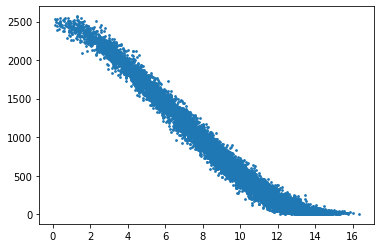

In [11]:
import matplotlib.pyplot as plt

plt.scatter([e['b'] for e in events], [len(e['px']) for e in events], s=3)
plt.show()